# LSTM Forecasting — Store Sales

This notebook builds a sequence-to-sequence LSTM model that predicts the next 15 days of sales for each store/family pair.

**Architecture**: Bidirectional LSTM → Dropout → Linear → 15 outputs  
**Target**: log1p(sales) — same as XGBoost baseline  
**Input**: 28-day window × 12 time features per step

Pipeline:
1. Load and prepare features
2. Build sequence dataset (28 days in → 15 days out)
3. Define LSTM model in PyTorch
4. Train with early stopping
5. Evaluate and compare to XGBoost baseline

## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print(f'PyTorch version : {torch.__version__}')
print(f'GPU available   : {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {device}')

PyTorch version : 2.10.0+cu128
GPU available   : True
Using device    : cuda


## 2. Load data

In [2]:
data_dir = Path('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting')

train_df = pd.read_parquet(data_dir / 'train.parquet')
val_df   = pd.read_parquet(data_dir / 'val.parquet')
test_df  = pd.read_parquet(data_dir / 'test.parquet')

train_end = train_df['date'].max()
val_end   = val_df['date'].max()

print(f'Train: {train_df.shape}  {train_df["date"].min()} → {train_end}')
print(f'Val  : {val_df.shape}   {val_df["date"].min()} → {val_end}')
print(f'Test : {test_df.shape}  {test_df["date"].min()} → {test_df["date"].max()}')

Train: (2918916, 23)  2013-01-01 00:00:00 → 2017-06-30 00:00:00
Val  : (53460, 23)   2017-07-01 00:00:00 → 2017-07-30 00:00:00
Test : (28512, 23)  2017-07-31 00:00:00 → 2017-08-15 00:00:00


## 3. Feature engineering

We add the same event features used in the XGBoost model, then build a single merged dataframe for sequence construction.

In [3]:
def add_event_features(df):
    df = df.copy()
    # Payday: 15th and last day of each month
    df['is_payday'] = (
        (df['date'].dt.day == 15) |
        (df['date'].dt.day == df['date'].dt.days_in_month)
    ).astype(int)
    # Days until next payday
    df['days_until_payday'] = df['date'].apply(
        lambda d: 15 - d.day if d.day < 15 else d.days_in_month - d.day
    )
    # Holiday scope flags
    df['is_national_holiday'] = (df['locale'] == 'National').astype(int)
    df['is_local_holiday']    = (df['locale'] == 'Local').astype(int)
    return df

train_df = add_event_features(train_df)
val_df   = add_event_features(val_df)
test_df  = add_event_features(test_df)
print('Event features added ')

Event features added 


In [4]:
# Merge into one timeline — required for sequence construction
lstm_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
lstm_df = lstm_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# Log-transform target
lstm_df['sales_log'] = np.log1p(lstm_df['sales'].clip(lower=0))

# Fill oil gaps
lstm_df['dcoilwtico'] = lstm_df['dcoilwtico'].interpolate(method='linear').bfill()

print(f'Total rows             : {len(lstm_df):,}')
print(f'Unique store/family    : {lstm_df.groupby(["store_nbr","family"]).ngroups}')
print(f'Date range             : {lstm_df["date"].min()} → {lstm_df["date"].max()}')

Total rows             : 3,000,888
Unique store/family    : 1782
Date range             : 2013-01-01 00:00:00 → 2017-08-15 00:00:00


## 4. Define features and normalize

In [5]:
WINDOW_SIZE = 28   # days of history the LSTM sees
HORIZON     = 15   # days ahead to predict

# Features at each timestep — all numerical
TIME_FEATURES = [
    'sales_log',
    'onpromotion',
    'is_holiday',
    'is_payday',
    'days_until_payday',
    'is_national_holiday',
    'is_local_holiday',
    'day_of_week',
    'month',
    'is_weekend',
    'is_month_end',
    'dcoilwtico',
]

# Verify all present
missing = [f for f in TIME_FEATURES if f not in lstm_df.columns]
if missing:
    raise ValueError(f'Missing features: {missing}')

print(f'Features per timestep  : {len(TIME_FEATURES)}')
print(f'Input shape per sample : ({WINDOW_SIZE}, {len(TIME_FEATURES)})')
print(f'Output shape per sample: ({HORIZON},)')
print(f'Features               : {TIME_FEATURES}')

Features per timestep  : 12
Input shape per sample : (28, 12)
Output shape per sample: (15,)
Features               : ['sales_log', 'onpromotion', 'is_holiday', 'is_payday', 'days_until_payday', 'is_national_holiday', 'is_local_holiday', 'day_of_week', 'month', 'is_weekend', 'is_month_end', 'dcoilwtico']


In [6]:
# Fit scaler on training rows only — no leakage
train_mask = lstm_df['date'] <= train_end

scaler = StandardScaler()
lstm_df.loc[train_mask,  TIME_FEATURES] = scaler.fit_transform(
    lstm_df.loc[train_mask, TIME_FEATURES]
)
lstm_df.loc[~train_mask, TIME_FEATURES] = scaler.transform(
    lstm_df.loc[~train_mask, TIME_FEATURES]
)

print('Normalization fitted on train only')
print(f'Feature means (first 3): {scaler.mean_[:3].round(4)}')
print(f'Feature stds  (first 3): {scaler.scale_[:3].round(4)}')

Normalization fitted on train only
Feature means (first 3): [2.9067 2.4808 1.    ]
Feature stds  (first 3): [ 2.6968 12.0074  1.    ]


## 5. Sequence dataset

For each (store, family) pair we slide a window of 28 days and collect the next 15 days as the target.

- **Train samples**: windows whose prediction starts on or before `train_end`
- **Val samples**: windows whose prediction starts after `train_end` and on or before `val_end`
- **Test samples**: windows whose prediction starts after `val_end`

In [7]:
class SalesSequenceDataset(Dataset):
    def __init__(self, df, split='train', window=WINDOW_SIZE, horizon=HORIZON):
        self.samples = []
        self.targets = []

        for (store, family), grp in df.groupby(['store_nbr', 'family']):
            grp = grp.sort_values('date').reset_index(drop=True)
            if len(grp) < window + horizon:
                continue

            feats  = grp[TIME_FEATURES].values.astype(np.float32)   # (T, F)
            target = grp['sales_log'].values.astype(np.float32)     # (T,)
            dates  = grp['date'].values

            for i in range(window, len(grp) - horizon + 1):
                pred_start = dates[i]

                if   split == 'train' and pred_start <= train_end:
                    pass
                elif split == 'val'   and train_end < pred_start <= val_end:
                    pass
                elif split == 'test'  and pred_start > val_end:
                    pass
                else:
                    continue

                self.samples.append(feats[i - window : i])     # (28, F)
                self.targets.append(target[i : i + horizon])   # (15,)

        self.samples = np.array(self.samples, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        print(f'[{split:5s}] samples: {self.samples.shape},  targets: {self.targets.shape}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return (torch.tensor(self.samples[idx]),
                torch.tensor(self.targets[idx]))


print('Building datasets — may take 1-2 minutes...')
train_dataset = SalesSequenceDataset(lstm_df, split='train')
val_dataset   = SalesSequenceDataset(lstm_df, split='val')
test_dataset  = SalesSequenceDataset(lstm_df, split='test')

Building datasets — may take 1-2 minutes...
[train] samples: (2869020, 28, 12),  targets: (2869020, 15)
[val  ] samples: (53460, 28, 12),  targets: (53460, 15)
[test ] samples: (3564, 28, 12),  targets: (3564, 15)


In [8]:
BATCH_SIZE = 2048

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Sanity check — inspect one batch
xb, yb = next(iter(train_loader))
print(f'\nBatch X shape : {xb.shape}   (batch, window, features)')
print(f'Batch y shape : {yb.shape}   (batch, horizon)')

Train batches : 1401
Val batches   : 27
Test batches  : 2

Batch X shape : torch.Size([2048, 28, 12])   (batch, window, features)
Batch y shape : torch.Size([2048, 15])   (batch, horizon)


## 6. Model definition

**Architecture**:
- Input: (batch, 28, 12)
- Bidirectional LSTM — 2 layers, hidden size 128
- Dropout 0.3 between LSTM and head
- Linear head → 15 outputs (one per forecast day)

Bidirectional means the LSTM reads the 28-day window both forward and backward, capturing patterns that are easier to see from the end of the sequence.

In [9]:
class SalesLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 horizon=HORIZON, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
            bidirectional = True,
        )

        self.dropout = nn.Dropout(dropout)

        # Bidirectional doubles the output size
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, horizon),
        )

    def forward(self, x):
        # x: (batch, window, features)
        out, _ = self.lstm(x)       # out: (batch, window, hidden*2)
        last   = out[:, -1, :]      # take last timestep: (batch, hidden*2)
        last   = self.dropout(last)
        return self.head(last)      # (batch, horizon)


INPUT_SIZE = len(TIME_FEATURES)

model = SalesLSTM(input_size=INPUT_SIZE).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

SalesLSTM(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=15, bias=True)
  )
)

Total trainable parameters: 558,095


## 7. Training

- **Loss**: MSE on log1p(sales) — equivalent to minimizing RMSLE
- **Optimizer**: AdamW with weight decay
- **Scheduler**: ReduceLROnPlateau — halves LR when val loss stalls
- **Early stopping**: stops after 5 epochs without improvement

In [10]:
def rmsle(y_true, y_pred):
    """Compute RMSLE on raw (non-log) sales arrays."""
    y_true = np.maximum(0, np.array(y_true))
    y_pred = np.maximum(0, np.array(y_pred))
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


def evaluate(model, loader, device):
    """Return average MSE loss and RMSLE on a dataloader."""
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0.0
    criterion = nn.MSELoss()

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss  = criterion(preds, yb)
            total_loss += loss.item() * len(xb)

            # Convert log predictions back to real sales for RMSLE
            all_preds.append(np.expm1(preds.cpu().numpy()))
            all_targets.append(np.expm1(yb.cpu().numpy()))

    avg_loss = total_loss / len(loader.dataset)
    preds_flat   = np.concatenate(all_preds).ravel()
    targets_flat = np.concatenate(all_targets).ravel()
    score = rmsle(targets_flat, preds_flat)
    return avg_loss, score

In [11]:
EPOCHS    = 30
LR        = 1e-3
PATIENCE  = 5   # early stopping patience

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
criterion = nn.MSELoss()

best_val_loss  = float('inf')
best_state     = None
patience_count = 0
history        = {'train_loss': [], 'val_loss': [], 'val_rmsle': []}

print(f'Training on {device} for up to {EPOCHS} epochs')
print(f'Train samples: {len(train_dataset):,}   Val samples: {len(val_dataset):,}')
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(xb)

    train_loss /= len(train_dataset)

    # --- Validate ---
    val_loss, val_rmsle = evaluate(model, val_loader, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_rmsle'].append(val_rmsle)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train loss: {train_loss:.4f} | '
          f'Val loss: {val_loss:.4f} | '
          f'Val RMSLE: {val_rmsle:.4f}')

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.')
            break

print('\nTraining complete ')
print(f'Best val loss  : {best_val_loss:.4f}')
print(f'Best val RMSLE : {min(history["val_rmsle"]):.4f}')

Training on cuda for up to 30 epochs
Train samples: 2,869,020   Val samples: 53,460
------------------------------------------------------------
Epoch 01/30 | Train loss: 0.0707 | Val loss: 0.0288 | Val RMSLE: 0.0986
Epoch 02/30 | Train loss: 0.0488 | Val loss: 0.0275 | Val RMSLE: 0.0951
Epoch 03/30 | Train loss: 0.0410 | Val loss: 0.0272 | Val RMSLE: 0.0926
Epoch 04/30 | Train loss: 0.0373 | Val loss: 0.0270 | Val RMSLE: 0.0903
Epoch 05/30 | Train loss: 0.0357 | Val loss: 0.0263 | Val RMSLE: 0.0909
Epoch 06/30 | Train loss: 0.0348 | Val loss: 0.0261 | Val RMSLE: 0.0872
Epoch 07/30 | Train loss: 0.0341 | Val loss: 0.0259 | Val RMSLE: 0.0872
Epoch 08/30 | Train loss: 0.0335 | Val loss: 0.0266 | Val RMSLE: 0.0885
Epoch 09/30 | Train loss: 0.0330 | Val loss: 0.0260 | Val RMSLE: 0.0871
Epoch 10/30 | Train loss: 0.0327 | Val loss: 0.0261 | Val RMSLE: 0.0891
Epoch 11/30 | Train loss: 0.0320 | Val loss: 0.0257 | Val RMSLE: 0.0875
Epoch 12/30 | Train loss: 0.0318 | Val loss: 0.0258 | Val RMSLE

## 8. Restore best model and evaluate on test set

In [12]:
# Restore best checkpoint
model.load_state_dict(best_state)
model.to(device)
print('Best model restored ')

# Final evaluation
val_loss,  val_rmsle  = evaluate(model, val_loader,  device)
test_loss, test_rmsle = evaluate(model, test_loader, device)

print(f'\nVal  RMSLE : {val_rmsle:.4f}')
print(f'Test RMSLE : {test_rmsle:.4f}')
print(f'Gap        : {test_rmsle - val_rmsle:.4f}')
print(f'\nXGBoost baseline — Val: 0.3733 | Test: 0.3863')
print(f'LSTM             — Val: {val_rmsle:.4f} | Test: {test_rmsle:.4f}')

Best model restored 

Val  RMSLE : 0.0845
Test RMSLE : 0.0997
Gap        : 0.0153

XGBoost baseline — Val: 0.3733 | Test: 0.3863
LSTM             — Val: 0.0845 | Test: 0.0997


In [13]:
import torch
torch.save(best_state, "/kaggle/working/lstm_best_model.pt")

## 9. Training curves

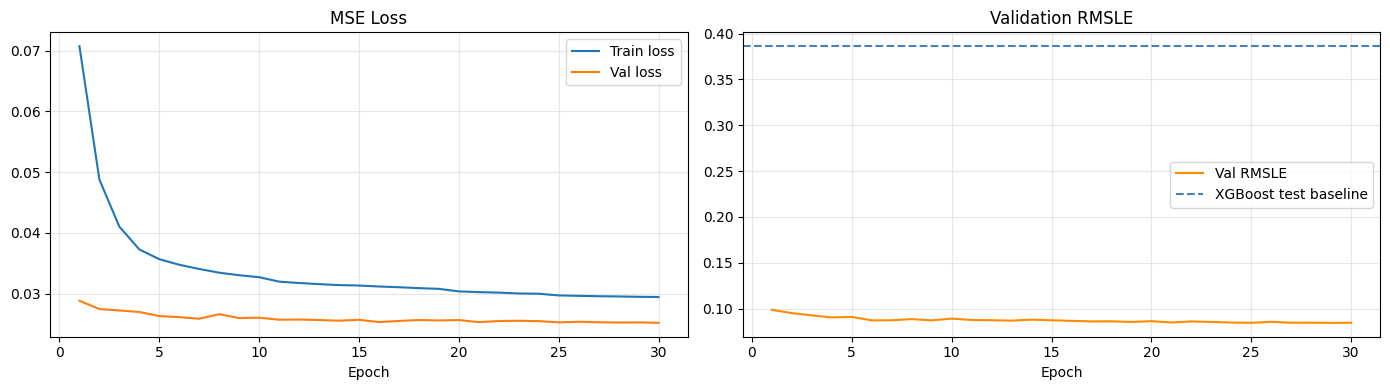

In [14]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train loss')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['val_rmsle'], color='darkorange', label='Val RMSLE')
axes[1].axhline(0.3863, color='steelblue', linestyle='--', label='XGBoost test baseline')
axes[1].set_title('Validation RMSLE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Qualitative check — predicted vs actual for one series

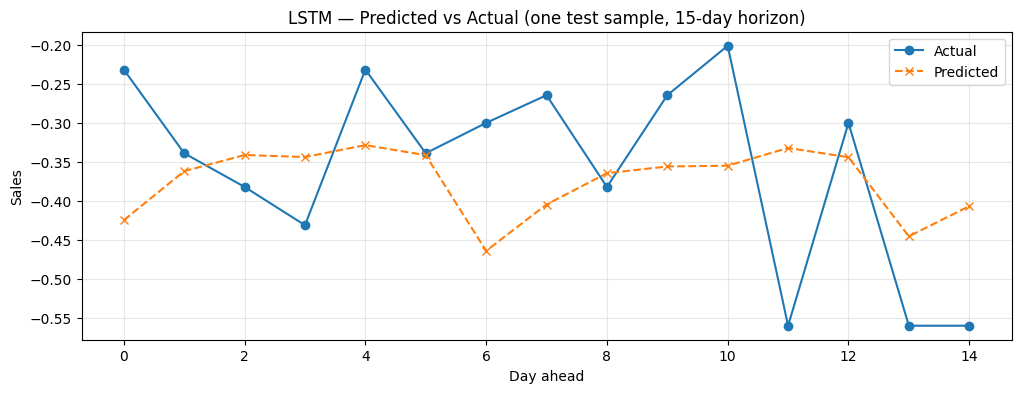

In [15]:
# Pick one store/family from the test set
model.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    preds = model(xb.to(device)).cpu().numpy()

# Convert from log space
preds_actual  = np.expm1(preds)
targets_actual = np.expm1(yb.numpy())

# Plot first sample in the batch
sample_idx = 0
plt.figure(figsize=(12, 4))
plt.plot(range(HORIZON), targets_actual[sample_idx], label='Actual',    marker='o')
plt.plot(range(HORIZON), preds_actual[sample_idx],   label='Predicted', marker='x', linestyle='--')
plt.title('LSTM — Predicted vs Actual (one test sample, 15-day horizon)')
plt.xlabel('Day ahead')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Save model checkpoint

In [16]:
checkpoint = {
    'model_state_dict' : best_state,
    'scaler'           : scaler,
    'time_features'    : TIME_FEATURES,
    'window_size'      : WINDOW_SIZE,
    'horizon'          : HORIZON,
    'val_rmsle'        : val_rmsle,
    'test_rmsle'       : test_rmsle,
}

torch.save(checkpoint, 'lstm_sales_checkpoint.pt')
print('Checkpoint saved → lstm_sales_checkpoint.pt ')
print(f'Val RMSLE  : {val_rmsle:.4f}')
print(f'Test RMSLE : {test_rmsle:.4f}')

Checkpoint saved → lstm_sales_checkpoint.pt 
Val RMSLE  : 0.0845
Test RMSLE : 0.0997


In [24]:
import torch.nn as nn

TIME_FEATURES = [
    'sales_log', 'onpromotion', 'is_holiday', 'is_payday',
    'days_until_payday', 'is_national_holiday', 'is_local_holiday',
    'day_of_week', 'month', 'is_weekend', 'is_month_end', 'dcoilwtico',
]

WINDOW_SIZE = 28
HORIZON     = 15
INPUT_SIZE  = len(TIME_FEATURES)

class SalesLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 horizon=HORIZON, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = True,
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, horizon),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last   = out[:, -1, :]
        last   = self.dropout(last)
        return self.head(last)

model = SalesLSTM(input_size=INPUT_SIZE).to(device)
print(f"Model defined ✅ — {sum(p.numel() for p in model.parameters()):,} parameters")

Model defined ✅ — 558,095 parameters


In [26]:
import torch
import numpy as np
import pandas as pd

# Load checkpoint
checkpoint = torch.load(
    '/kaggle/input/models/montahalassouedd/lstm-model/other/default/1/lstm_sales_checkpoint.pt',
    map_location=device,
    weights_only=False
)

# Restore model
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print(f"Model restored ")
print(f"Val RMSLE  from checkpoint : {checkpoint['val_rmsle']:.4f}")
print(f"Test RMSLE from checkpoint : {checkpoint['test_rmsle']:.4f}")
print(f"Window size : {checkpoint['window_size']}")
print(f"Horizon     : {checkpoint['horizon']}")

Model restored 
Val RMSLE  from checkpoint : 0.0845
Test RMSLE from checkpoint : 0.0997
Window size : 28
Horizon     : 15


In [27]:
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print(f"Weights loaded ")
print(f"Val RMSLE  : {checkpoint['val_rmsle']:.4f}")
print(f"Test RMSLE : {checkpoint['test_rmsle']:.4f}")

Weights loaded ✅
Val RMSLE  : 0.0845
Test RMSLE : 0.0997


In [50]:
model.eval()
all_preds = []

for (store, family), grp in lstm_df.groupby(['store_nbr', 'family']):
    grp = grp.sort_values('date').reset_index(drop=True)
    dates = grp['date'].values
    feats = grp[TIME_FEATURES].values.astype(np.float32)

    for i in range(WINDOW_SIZE, len(grp) - HORIZON + 1):
        pred_start = dates[i]
        if pred_start <= val_end:
            continue

        x = torch.tensor(feats[i - WINDOW_SIZE:i]).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_log = model(x).cpu().numpy().squeeze()

        # Convert from log space — no hard clip, only remove negatives
        pred_actual = np.expm1(pred_log)
        pred_actual = np.where(pred_actual < 0, 0, pred_actual)

        for day_offset in range(HORIZON):
            if i + day_offset >= len(dates):
                break
            all_preds.append({
                'store_nbr' : store,
                'family'    : family,
                'date'      : dates[i + day_offset],
                'lstm_pred' : pred_actual[day_offset],
            })

lstm_preds_df = pd.DataFrame(all_preds)
lstm_preds_df = lstm_preds_df.groupby(
    ['store_nbr', 'family', 'date']
)['lstm_pred'].mean().reset_index()

print(f"LSTM predictions shape : {lstm_preds_df.shape}")
print(f"Zero predictions       : {(lstm_preds_df['lstm_pred'] == 0).sum()}")
print(lstm_preds_df.head(10))

LSTM predictions shape : (28512, 4)
Zero predictions       : 12454
   store_nbr      family       date  lstm_pred
0          1  AUTOMOTIVE 2017-07-31        0.0
1          1  AUTOMOTIVE 2017-08-01        0.0
2          1  AUTOMOTIVE 2017-08-02        0.0
3          1  AUTOMOTIVE 2017-08-03        0.0
4          1  AUTOMOTIVE 2017-08-04        0.0
5          1  AUTOMOTIVE 2017-08-05        0.0
6          1  AUTOMOTIVE 2017-08-06        0.0
7          1  AUTOMOTIVE 2017-08-07        0.0
8          1  AUTOMOTIVE 2017-08-08        0.0
9          1  AUTOMOTIVE 2017-08-09        0.0


In [53]:
model.eval()
all_preds = []

# Get the index of sales_log in TIME_FEATURES
sales_log_idx = TIME_FEATURES.index('sales_log')
sales_mean = scaler.mean_[sales_log_idx]
sales_std  = scaler.scale_[sales_log_idx]

print(f"sales_log mean (scaler): {sales_mean:.4f}")
print(f"sales_log std  (scaler): {sales_std:.4f}")

for (store, family), grp in lstm_df.groupby(['store_nbr', 'family']):
    grp = grp.sort_values('date').reset_index(drop=True)
    dates = grp['date'].values
    feats = grp[TIME_FEATURES].values.astype(np.float32)

    for i in range(WINDOW_SIZE, len(grp) - HORIZON + 1):
        pred_start = dates[i]
        if pred_start <= val_end:
            continue

        x = torch.tensor(feats[i - WINDOW_SIZE:i]).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_log_normalized = model(x).cpu().numpy().squeeze()

        # Inverse normalize: from normalized log space → real log space
        pred_log_real = pred_log_normalized * sales_std + sales_mean

        # Convert from log space to real sales
        pred_actual = np.expm1(pred_log_real).clip(min=0)

        for day_offset in range(HORIZON):
            if i + day_offset >= len(dates):
                break
            all_preds.append({
                'store_nbr' : store,
                'family'    : family,
                'date'      : dates[i + day_offset],
                'lstm_pred' : pred_actual[day_offset],
            })

lstm_preds_df = pd.DataFrame(all_preds)
lstm_preds_df = lstm_preds_df.groupby(
    ['store_nbr', 'family', 'date']
)['lstm_pred'].mean().reset_index()

print(f"\nLSTM predictions shape : {lstm_preds_df.shape}")
print(f"Zero predictions       : {(lstm_preds_df['lstm_pred'] == 0).sum()}")
print(f"\nSample AUTOMOTIVE:")
print(lstm_preds_df[lstm_preds_df['family'] == 'AUTOMOTIVE'].head(5).to_string())
print(f"\nSample GROCERY I:")
print(lstm_preds_df[lstm_preds_df['family'] == 'GROCERY I'].head(5).to_string())

sales_log mean (scaler): 2.9067
sales_log std  (scaler): 2.6968

LSTM predictions shape : (28512, 4)
Zero predictions       : 109

Sample AUTOMOTIVE:
   store_nbr      family       date  lstm_pred
0          1  AUTOMOTIVE 2017-07-31   3.123670
1          1  AUTOMOTIVE 2017-08-01   5.052464
2          1  AUTOMOTIVE 2017-08-02   5.301911
3          1  AUTOMOTIVE 2017-08-03   4.980099
4          1  AUTOMOTIVE 2017-08-04   5.548697

Sample GROCERY I:
     store_nbr     family       date    lstm_pred
192          1  GROCERY I 2017-07-31  2056.163732
193          1  GROCERY I 2017-08-01  2527.380072
194          1  GROCERY I 2017-08-02  3172.592411
195          1  GROCERY I 2017-08-03  2304.183506
196          1  GROCERY I 2017-08-04  2709.462199


In [62]:
import pickle

with open('/kaggle/input/models/montahalassouedd/xgboost/other/default/1/forecast_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

print(f"Model loaded: {type(xgb_model)}")

Model loaded: <class 'xgboost.sklearn.XGBRegressor'>


In [76]:
from pathlib import Path
import numpy as np
import pandas as pd

data_dir = Path('/kaggle/input/datasets/montahalassouedd/processed-data-stores-forecasting')

train_df = pd.read_parquet(data_dir / 'train.parquet')
val_df   = pd.read_parquet(data_dir / 'val.parquet')
test_df  = pd.read_parquet(data_dir / 'test.parquet')

train_end = train_df['date'].max()
val_end   = val_df['date'].max()

def add_event_features(df):
    df = df.copy()
    df['is_payday'] = (
        (df['date'].dt.day == 15) |
        (df['date'].dt.day == df['date'].dt.days_in_month)
    ).astype(int)
    df['days_until_payday'] = df['date'].apply(
        lambda d: 15 - d.day if d.day < 15 else d.days_in_month - d.day
    )
    df['is_national_holiday'] = (df['locale'] == 'National').astype(int)
    df['is_local_holiday']    = (df['locale'] == 'Local').astype(int)
    return df

train_df = add_event_features(train_df)
val_df   = add_event_features(val_df)
test_df  = add_event_features(test_df)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

Train: (2918916, 27), Val: (53460, 27), Test: (28512, 27)


In [78]:
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
full_df = full_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

grp = full_df.groupby(['store_nbr', 'family'])['sales']
full_df['lag_1']  = grp.shift(1)
full_df['lag_7']  = grp.shift(7)
full_df['lag_14'] = grp.shift(14)
full_df['lag_28'] = grp.shift(28)
full_df['roll_mean_7']  = grp.shift(1).transform(lambda x: x.rolling(7,  min_periods=1).mean())
full_df['roll_mean_28'] = grp.shift(1).transform(lambda x: x.rolling(28, min_periods=1).mean())
full_df['roll_std_7']   = grp.shift(1).transform(lambda x: x.rolling(7,  min_periods=1).std()).fillna(0)
full_df['transactions_lag_1'] = full_df.groupby('store_nbr')['transactions'].shift(1)
full_df['dcoilwtico'] = full_df['dcoilwtico'].interpolate(method='linear').bfill()
full_df['oil_trend']  = full_df['dcoilwtico'].rolling(window=3, min_periods=1).mean()

train_df = full_df[full_df['date'] <= train_end].copy()
val_df   = full_df[(full_df['date'] > train_end) & (full_df['date'] <= val_end)].copy()
test_df  = full_df[full_df['date'] > val_end].copy()

print(f"Test rebuilt: {test_df.shape}")

Test rebuilt: (28512, 36)


In [79]:
drop_cols = ['sales', 'date', 'transactions', 'holiday_type']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['sales'].astype(float)

cat_cols = X_test.select_dtypes(include='category').columns.tolist()
for col in cat_cols:
    X_test[col] = X_test[col].cat.codes

lag_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_28',
            'roll_mean_7', 'roll_mean_28', 'roll_std_7',
            'transactions_lag_1']
for col in lag_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].fillna(0)

print(f"X_test shape  : {X_test.shape}")
print(f"Remaining NaNs: {X_test.isnull().sum().sum()}")

X_test shape  : (28512, 33)
Remaining NaNs: 0


In [83]:
from sklearn.preprocessing import LabelEncoder

# Encode all object columns
object_cols = X_test.select_dtypes(include='object').columns.tolist()
print(f"Object columns to encode: {object_cols}")

le = LabelEncoder()
for col in object_cols:
    X_test[col] = le.fit_transform(X_test[col].astype(str))

print(f"X_test dtypes after encoding:")
print(X_test.dtypes.value_counts())
print(f"Remaining object cols: {X_test.select_dtypes(include='object').columns.tolist()}")

Object columns to encode: ['family', 'city', 'state', 'type_x', 'type_y', 'locale', 'locale_name']
X_test dtypes after encoding:
int64      14
float64    10
int32       8
bool        1
Name: count, dtype: int64
Remaining object cols: []


In [87]:
# These are exactly the columns the model was trained on
xgb_features = [
    'store_nbr', 'family', 'onpromotion', 'city', 'state', 'type_x',
    'cluster', 'dcoilwtico', 'type_y', 'locale', 'locale_name',
    'transferred', 'day_of_week', 'month', 'quarter', 'is_weekend',
    'is_month_start', 'is_month_end', 'has_promotion', 'is_holiday',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'transactions_lag_1'
]

xgb_preds_df = test_df[['store_nbr', 'family', 'date']].copy()
xgb_preds_df['xgb_pred'] = np.expm1(
    xgb_model.predict(X_test[xgb_features])
).clip(min=0)

print(f"XGBoost predictions: {xgb_preds_df.shape}")
print(xgb_preds_df.head())

XGBoost predictions: (28512, 4)
      store_nbr      family       date  xgb_pred
1668          1  AUTOMOTIVE 2017-07-31  3.549983
1669          1  AUTOMOTIVE 2017-08-01  4.233465
1670          1  AUTOMOTIVE 2017-08-02  4.069101
1671          1  AUTOMOTIVE 2017-08-03  4.055697
1672          1  AUTOMOTIVE 2017-08-04  4.241306


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [10:33:37] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [89]:
# Merge XGBoost and LSTM predictions
ensemble_df = xgb_preds_df.merge(
    lstm_preds_df,
    on=['store_nbr', 'family', 'date'],
    how='inner'
)

# Merge actual sales
actuals = test_df[['store_nbr', 'family', 'date', 'sales']].copy()
ensemble_df = ensemble_df.merge(
    actuals,
    on=['store_nbr', 'family', 'date'],
    how='inner'
)

print(f"Ensemble rows : {ensemble_df.shape}")

def rmsle(y_true, y_pred):
    y_true = np.maximum(0, np.array(y_true))
    y_pred = np.maximum(0, np.array(y_pred))
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

y_true     = ensemble_df['sales'].values
xgb_score  = rmsle(y_true, ensemble_df['xgb_pred'].values)
lstm_score = rmsle(y_true, ensemble_df['lstm_pred'].values)
ens_70_30  = rmsle(y_true, 0.7 * ensemble_df['xgb_pred'] + 0.3 * ensemble_df['lstm_pred'])
ens_50_50  = rmsle(y_true, 0.5 * ensemble_df['xgb_pred'] + 0.5 * ensemble_df['lstm_pred'])
ens_30_70  = rmsle(y_true, 0.3 * ensemble_df['xgb_pred'] + 0.7 * ensemble_df['lstm_pred'])
ens_20_80  = rmsle(y_true, 0.2 * ensemble_df['xgb_pred'] + 0.8 * ensemble_df['lstm_pred'])

print("=" * 45)
print(f"{'Model':<30} {'RMSLE':>10}")
print("=" * 45)
print(f"{'XGBoost alone':<30} {xgb_score:>10.4f}")
print(f"{'LSTM alone':<30} {lstm_score:>10.4f}")
print(f"{'Ensemble 70% XGB + 30% LSTM':<30} {ens_70_30:>10.4f}")
print(f"{'Ensemble 50% XGB + 50% LSTM':<30} {ens_50_50:>10.4f}")
print(f"{'Ensemble 30% XGB + 70% LSTM':<30} {ens_30_70:>10.4f}")
print(f"{'Ensemble 20% XGB + 80% LSTM':<30} {ens_20_80:>10.4f}")
print("=" * 45)

Ensemble rows : (28512, 6)
Model                               RMSLE
XGBoost alone                      0.3927
LSTM alone                         0.4730
Ensemble 70% XGB + 30% LSTM        0.3890
Ensemble 50% XGB + 50% LSTM        0.3934
Ensemble 30% XGB + 70% LSTM        0.4044
Ensemble 20% XGB + 80% LSTM        0.4138
